In [1]:
from shapely.geometry import shape
import json
import pandas as pd
import pandas as pd
import matplotlib.colors as mcolors
import statsmodels.api as sm
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import utils.analysis_functions as af
from scipy.signal import detrend

In [3]:
PID_df=pd.read_csv('data/lookup/PID_location_all.csv')
csc_df= pd.read_csv('data/processed/PID_location_WSCI.csv')
npp_df=pd.read_csv('data/processed/PID_npp.csv')

PID_df, csc_df, npp_df = af.cleaning(PID_df, csc_df, npp_df)

In [4]:
npp_df.rename(columns={'NPP_kgC_m2_yr': "Npp"}, inplace=True)

grouped = npp_df.groupby('PID').apply(lambda x: x.sort_values('year')['Npp'].to_numpy())

KeyboardInterrupt: 

In [ ]:
grouped = grouped[grouped.apply(lambda x: ~np.isnan(x).any())]

In [ ]:
def compute_volatility(arr): 
    '''
    Log of inverse CoV

    '''
    s=arr.mean()
    sd=arr.std()
    arr= pd.Series(detrend(arr*10))
    
    v= np.log(s/arr.std())
    return v , s, sd

In [ ]:
volatility=[]
PID_list=[]
mean=[]
sad=[]
for pid, arr in grouped.items():
    if arr.shape[0] > 5:
        if (arr == 0).sum() < 4: 
            v , s, sd = compute_volatility(arr)
            # returns = np.diff(arr) / arr[:-1]

            # returns = np.abs(returns)
            # v = np.std(returns, ddof=1)
            volatility.append(v)
            PID_list.append(pid)
            mean.append(s)
            sad.append(sd)

npp_df1 = pd.DataFrame({'PID': PID_list, 'transformed npp': volatility, 'mean': mean, 'sd': sad })

In [24]:
npp_total=npp_df1.merge(npp_df2, how='inner', on='PID')

# npp_df1.to_csv("npp_cov.csv", index=False)

In [25]:
npp_total

,PID,transformed npp_x,mean_x,sd_x,transformed npp_y,mean_y,sd_y
0,0_41_27_17_550,0.211252,0.82354,0.066350,0.265402,0.847743,0.064164
1,0_41_27_51502_502,0.428202,0.82017,0.057273,0.395128,0.816300,0.067095
2,0_41_27_56058_502,0.525786,0.81020,0.046352,0.449099,0.811586,0.052691
3,0_41_27_56573_502,0.715363,0.78908,0.036685,0.856746,0.798971,0.036590
4,0_41_27_56962_502,0.781829,0.82405,0.036343,0.927058,0.828414,0.039149
...,...,...,...,...,...,...,...
122634,9_53_65_97682_501,0.038433,0.50623,0.047532,0.044171,0.497186,0.044756
122635,9_53_65_98441_501,0.025172,0.55778,0.051905,-0.134391,0.554914,0.058769
122636,9_53_71_93609_501,0.468799,0.60615,0.037801,0.300040,0.598343,0.041304
122637,9_53_75_61977_501,0.157621,0.40597,0.033742,0.849255,0.400843,0.016102


Text(0, 0.5, 'Mean NPP (2013-2019)')

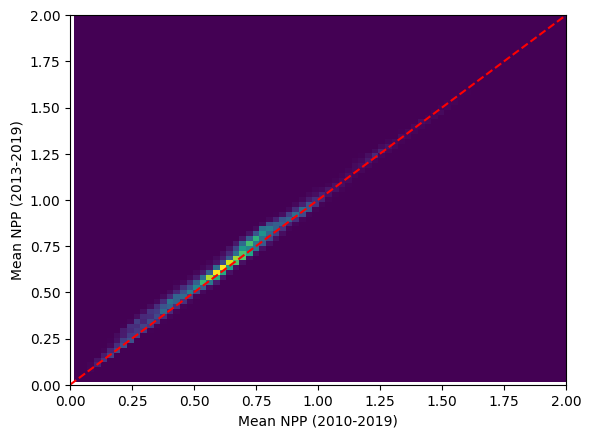

In [37]:
plt.hist2d(npp_total['mean_x'], npp_total['mean_y'], bins=90, cmap='viridis')

x = np.linspace(0, 2, 100)

# 1-1 line
y = x

plt.plot(x, y, linestyle='--', label='1:1 line', color='red')

plt.xlim(0., 2)
plt.ylim(0.,2)
plt.xlabel('Mean NPP (2010-2019)')
plt.ylabel('Mean NPP (2013-2019)')

In [ ]:
print(npp_total['sd_x'].corr(npp_total['sd_y']),
    npp_total['mean_x'].corr(npp_total['mean_y']),
    npp_total['transformed npp_x'].corr(npp_total['transformed npp_y'])
)


np.float64(0.9441518571846522)

In [9]:
from scipy.stats import pearsonr

print('SD:', pearsonr(npp_df1['mean'], npp_df1['transformed npp']))

SD: PearsonRResult(statistic=np.float64(0.4512827641205314), pvalue=np.float64(0.0))


Text(0, 0.5, 'Inverse CoV')

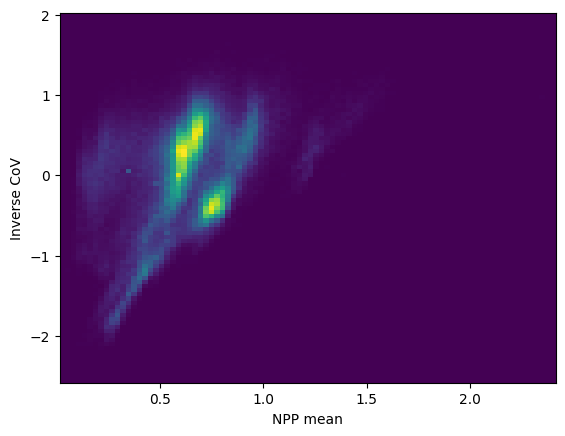

In [10]:
plt.hist2d(npp_df1['mean'], npp_df1['transformed npp'], bins=90, cmap='viridis')

plt.xlabel('NPP mean')
plt.ylabel('Inverse CoV')

In [11]:
npp_df1

,PID,transformed npp,mean,sd
0,0_41_27_10_550,0.891192,0.772582,0.034555
1,0_41_27_12_550,0.742030,0.852236,0.052425
2,0_41_27_15_550,0.179211,0.786809,0.066700
3,0_41_27_16_550,0.831042,0.804009,0.035473
4,0_41_27_17_550,0.310456,0.825918,0.063707
...,...,...,...,...
400160,9_53_75_61977_501,0.126766,0.411100,0.036030
400161,9_53_75_62722_501,0.674868,0.459855,0.024405
400162,9_53_75_72668_501,0.281854,0.291136,0.021857
400163,9_53_75_93825_501,0.183917,0.421345,0.034540


In [25]:
npp_df1['transformed npp'].nsmallest(20)

32521    -2.826525
10990    -2.648856
10991    -2.648856
32448    -2.550696
32514    -2.486365
32496    -2.470992
32511    -2.426043
15585    -2.365064
108997   -2.360868
90173    -2.349288
15584    -2.253364
32504    -2.236316
32512    -2.232990
32282    -2.211576
32303    -2.174974
11003    -2.165519
11004    -2.165519
32493    -2.136888
32311    -2.131569
47023    -2.125787
Name: transformed npp, dtype: float64

In [12]:
npp_df1['transformed npp'].nlargest(20)

392594    2.021611
392637    2.017367
392638    2.017367
337621    1.957021
34222     1.947486
34322     1.939228
392628    1.914295
392593    1.906993
392597    1.890473
34306     1.880317
392603    1.812448
378579    1.801798
378580    1.801798
392606    1.771811
392590    1.770053
82550     1.769362
82551     1.769362
67032     1.768359
67033     1.768359
304325    1.764774
Name: transformed npp, dtype: float64

In [13]:
rows= npp_df1[npp_df1['transformed npp'] >1.9]
rows

,PID,transformed npp,mean,sd
34222,1_25_5_242_1,1.947486,1.257145,0.020930
34322,1_25_7_809_111,1.939228,1.321509,0.032170
337621,4_6_81_17_555,1.957021,1.544200,0.022022
392593,8_36_103_190_101,1.906993,1.216764,0.019129
392594,8_36_103_192_101,2.021611,0.950227,0.013025
392628,8_36_103_4668_1,1.914295,1.171336,0.016482
392637,8_36_103_5980_1,2.017367,0.856691,0.011260
392638,8_36_103_5980_117,2.017367,0.856691,0.011260


In [14]:
rows = npp_df1[(npp_df1['transformed npp'] < 2) & (npp_df1['transformed npp'] >1)]
rows

,PID,transformed npp,mean,sd
150,0_41_47_61424_502,1.031695,0.841545,0.030097
256,0_41_47_95699_502,1.020093,0.862264,0.032030
282,0_41_51_62235_502,1.026321,0.913918,0.037126
318,0_41_51_9_550,1.154548,0.801818,0.028289
322,0_41_53_14_550,1.070510,0.819491,0.028421
...,...,...,...,...
398752,9_42_95_47_101,1.220187,0.700345,0.019959
398826,9_53_13_94833_501,1.132922,0.383291,0.016846
399693,9_53_63_51913_501,1.043700,0.509345,0.017991
399769,9_53_63_94875_501,1.043229,0.500218,0.017687


In [15]:
s_rows= npp_df1[npp_df1['transformed npp'] < -2]
s_rows


,PID,transformed npp,mean,sd
11811,1_13_161_2_1,-2.035312,0.250309,0.191146
11824,1_13_161_5_1,-2.100412,0.247291,0.198822
11825,1_13_161_6_1,-2.068568,0.242755,0.189340
11840,1_13_161_87_1,-2.133509,0.227091,0.189433
11893,1_13_161_90022_210,-2.026219,0.235136,0.176161
...,...,...,...,...
347484,5_22_111_90019_214,-2.095789,0.139355,0.140024
347485,5_22_111_90019_216,-2.095789,0.139355,0.140024
348716,5_22_21_54_1,-2.016572,0.153364,0.136749
349523,5_22_73_19_1,-2.041309,0.132218,0.123074


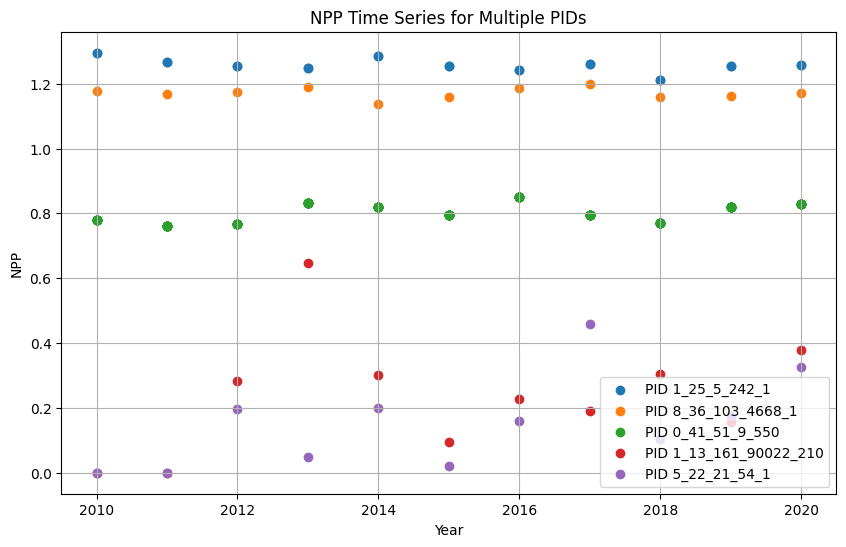

In [17]:
import matplotlib.pyplot as plt

# List of PIDs to plot
# pids_to_plot = ['1_64_60_65018_1', '1_32_21_396_420', '0_41_57_87607_502', '1_15_1_2364_1', '0_41_27_61522_502']
pids_to_plot =['1_25_5_242_1', '8_36_103_4668_1', '0_41_51_9_550', '1_13_161_90022_210', '5_22_21_54_1']
plt.figure(figsize=(10,6))

for pid in pids_to_plot:
    # Select rows for this PID
    selected_rows = npp_df[npp_df['PID'] == pid]
    # Scatter or line plot
    plt.scatter(selected_rows['year'], selected_rows['Npp'], marker='o', label=f'PID {pid}')

plt.xlabel('Year')
plt.ylabel('NPP')
plt.title('NPP Time Series for Multiple PIDs')
plt.legend()
plt.grid(True)
plt.show()

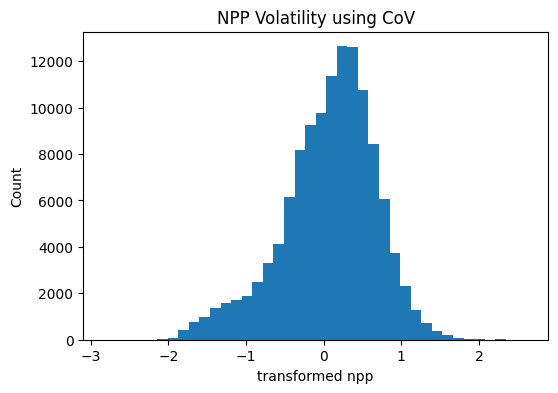

In [ ]:
x= "transformed npp"
title='Distribution of NPP transformed'

af.histogram(npp_df1, x, title)

In [18]:
total_df = npp_df1.merge(PID_df, on='PID', how='inner')
total_df.dropna(subset=["transformed npp"], inplace=True)

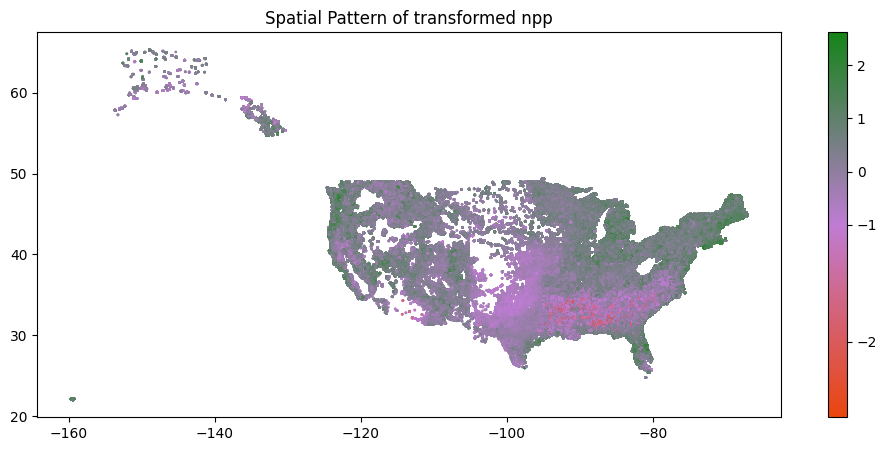

In [64]:
npp_value = 'transformed npp'
title = f"Spatial Pattern of {npp_value}"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#EA450E", "#BF7CD4", "#148418"]  # pink, zero, positive
)

af.spatial_scatter(total_df["lon"], total_df["lat"], total_df[npp_value], title, cmap, vcenter=-1)

In [19]:
merged_df = npp_df1.merge(csc_df, on='PID', how='left', suffixes=('_','_orig'))
merged_df = merged_df.drop(columns=[col for col in merged_df.columns if "orig" in col])
merged_df.dropna(subset=['WSCI', "transformed npp"], inplace=True)


# normalized = (merged_df['WSCI']-min(merged_df['WSCI']))/(max(merged_df['WSCI'])-min(merged_df['WSCI']))
# merged_df['Stability metric'] =  - normalized + (merged_df["transformed npp"])
# merged_df["BHAGE"] = merged_df["BHAGE"].fillna("0.0")


In [20]:
merged_df

,PID,transformed npp,mean,sd,lat_x,lon_x,BHAGE_x,managed_x,ownership_x,biome_x,WSCI,lat_y,lon_y,BHAGE_y,managed_y,ownership_y,biome_y
0,0_41_27_10_550,0.891192,0.772582,0.034555,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests,9.602610,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests
1,0_41_27_10_550,0.891192,0.772582,0.034555,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests,9.602610,45.583893,-121.558327,22.0,0.0,other,Temperate conifer forests
2,0_41_27_10_550,0.891192,0.772582,0.034555,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests,9.602610,45.583893,-121.558327,48.0,0.0,other,Temperate conifer forests
3,0_41_27_10_550,0.891192,0.772582,0.034555,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests,9.602610,45.583893,-121.558327,35.0,0.0,other,Temperate conifer forests
4,0_41_27_10_550,0.891192,0.772582,0.034555,45.583893,-121.558327,23.0,0.0,other,Temperate conifer forests,9.602610,45.583893,-121.558327,41.0,0.0,other,Temperate conifer forests
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1050733,9_53_75_93825_501,0.183917,0.421345,0.034540,46.948461,-117.426804,NaN,0.0,other,Temperate grasslands,9.576805,46.948461,-117.426804,NaN,0.0,other,Temperate grasslands
1050734,9_53_75_93825_501,0.183917,0.421345,0.034540,46.948461,-117.426804,NaN,0.0,other,Temperate grasslands,9.576805,46.948461,-117.426804,85.0,0.0,other,Temperate grasslands
1050735,9_53_75_94177_501,0.578539,0.406909,0.022624,47.251319,-117.428034,93.0,0.0,other,Temperate grasslands,8.993457,47.251319,-117.428034,93.0,0.0,other,Temperate grasslands
1050736,9_53_75_94177_501,0.578539,0.406909,0.022624,47.251319,-117.428034,93.0,0.0,other,Temperate grasslands,8.993457,47.251319,-117.428034,NaN,0.0,other,Temperate grasslands


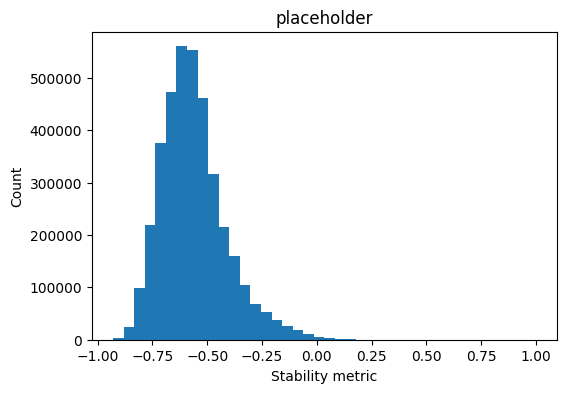

In [66]:
x= "Stability metric"
title='placeholder'

af.histogram(merged_df, x, title)

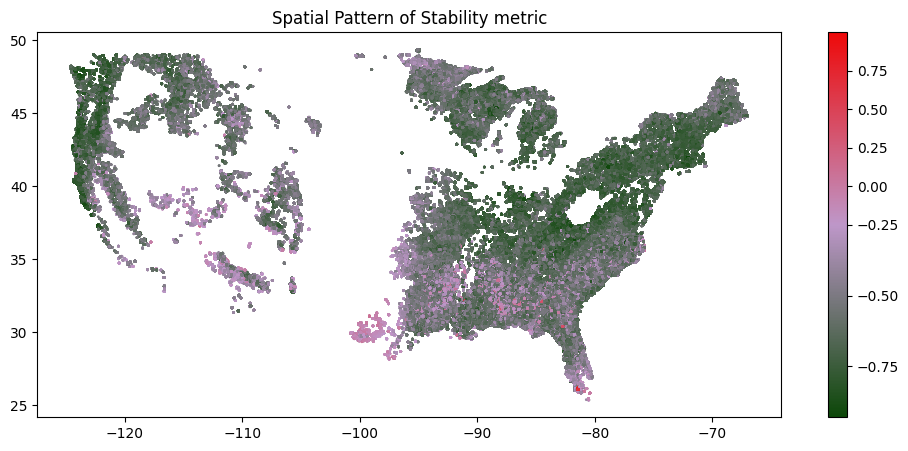

In [67]:
npp_value = 'Stability metric'
title = f"Spatial Pattern of {npp_value}"

cmap = mcolors.LinearSegmentedColormap.from_list(
    "red_white_green",
    ["#0C4708", "#BE97C9", "#EE0909"]  # pink, zero, positive
)

af.spatial_scatter(merged_df["lon"], merged_df["lat"], merged_df[npp_value], title, cmap, vcenter=-0.25)

In [20]:
merged_df

,PID,transformed npp,csc,lat,lon,BHAGE,managed,ownership,biome,Stability metric
0,0_41_27_17_550,-0.430580,10.687259,45.460278,-121.751396,50.0,1.0,other,Temperate conifer forests,-1.143952
1,0_41_27_17_550,-0.430580,10.687259,45.460278,-121.751396,51.0,1.0,other,Temperate conifer forests,-1.143952
2,0_41_27_17_550,-0.430580,10.687259,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,-1.143952
3,0_41_27_17_550,-0.430580,10.687259,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,-1.143952
4,0_41_27_17_550,-0.430580,10.687259,45.460278,-121.751396,48.0,1.0,other,Temperate conifer forests,-1.143952
...,...,...,...,...,...,...,...,...,...,...
3854754,9_53_71_93609_501,-0.813631,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-1.600945
3854755,9_53_71_93609_501,-0.813631,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-1.600945
3854756,9_53_71_93609_501,-0.813631,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-1.600945
3854757,9_53_71_93609_501,-0.813631,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-1.600945


In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.kdeplot(x=merged_df['transformed npp'], y=merged_df['WSCI'], cmap='viridis', fill=True, thresh=0, levels=50)
plt.xlabel('csc')
plt.ylabel('transformed npp')
plt.title('Kernel Density Estimate')
plt.show()

ValueError: autodetected range of [nan, nan] is not finite

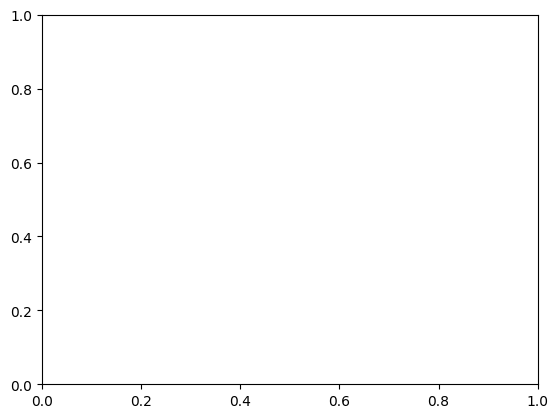

In [ ]:
import matplotlib.pyplot as plt

plt.hist2d(merged_df['mean'], np.log(merged_df['csc']), bins=50, cmap='viridis')
plt.colorbar(label='Number of points')
plt.xlabel('Npp')
plt.ylabel('CSC')
plt.title('Density Heatmap of mean npp vs csc')
plt.show()

In [12]:
merged_df

,PID,transformed npp,mean,csc,lat,lon,BHAGE,managed,ownership,biome,Stability metric
0,0_41_27_17_550,0.265402,0.847743,10.687259,45.460278,-121.751396,50.0,1.0,other,Temperate conifer forests,-0.447970
1,0_41_27_17_550,0.265402,0.847743,10.687259,45.460278,-121.751396,51.0,1.0,other,Temperate conifer forests,-0.447970
2,0_41_27_17_550,0.265402,0.847743,10.687259,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,-0.447970
3,0_41_27_17_550,0.265402,0.847743,10.687259,45.460278,-121.751396,56.0,1.0,other,Temperate conifer forests,-0.447970
4,0_41_27_17_550,0.265402,0.847743,10.687259,45.460278,-121.751396,48.0,1.0,other,Temperate conifer forests,-0.447970
...,...,...,...,...,...,...,...,...,...,...,...
3854754,9_53_71_93609_501,0.300040,0.598343,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-0.487274
3854755,9_53_71_93609_501,0.300040,0.598343,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-0.487274
3854756,9_53_71_93609_501,0.300040,0.598343,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-0.487274
3854757,9_53_71_93609_501,0.300040,0.598343,10.924962,46.040058,-118.053080,NaN,0.0,other,Temperate conifer forests,-0.487274
